# DUP — Historical Reference Model

| | |
|---|---|
| **Notebook** | `DUP__historical_reference_model.ipynb` |
| **Description** | Builds analyte-specific historical reference models for Duplicate QC samples using spline quantile regression of RPD against mean concentration. |
| **Author** | Rob Clark |
| **Created** | August 2026 / Semester 2 |
| **QC Type** | Duplicate |

## Change History

| Date | Author | Description |
|---|---|---|
| 2026-08-16 | R.Clark | (T32-141/T32-142) Developed pilot spline quantile regression reference model using Q25, Q50, Q75 and Q95. |
| 2026-08-23 | R.Clark | (T32-141/T32-143) Expanded historical reference model to 5 analytes and included concentration > 0. |
| 2026-08-30 | R.Clark | (T32-141/T32-231) Expanded historical reference model to all 41 eligible analytes and generated persisted reference model. |
| 2026-09-07 | R.Clark | (T32-141/T32-250) Added analyte-specific Statistical Detection Limit and Limiting Repeatability values, calculated concentration-dependent Allowable RPD, and incorporated the Limiting Repeatability curve into the persisted historical reference model and visualisations. |



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load prepared Duplicate QC dataset
df = pd.read_csv("../data/processed/duplicates_model.csv")

df.head()


,ANALYSED_DATE,ANALYTE_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,STAT_DL_DUP_VALUE,MEAN_CONC,ABS_DIFF,RPD,PRECISION_STATUS,LIM_REP_DUP_VALUE,UNIT_CODE
0,2021-05-10 11:39:33.000000,TA,3.378640,2.185365,12.5,2.782003,1.193275,42.89,Pass,15.0,MG_KG
1,2021-05-10 11:39:33.000000,TA,-0.746270,0.801886,12.5,0.027808,1.548156,5567.32,Pass,15.0,MG_KG
2,2021-05-10 11:39:33.000000,TA,1.879069,1.260273,12.5,1.569671,0.618796,39.42,Pass,15.0,MG_KG
3,2021-05-10 11:38:57.000000,TA,-3.129188,-2.010870,12.5,-2.570029,1.118317,-43.51,Pass,15.0,MG_KG
4,2021-05-10 11:38:57.000000,TA,-2.185186,-3.709679,12.5,-2.947432,1.524493,-51.72,Pass,15.0,MG_KG


In [3]:
# Historical reference population
accepted_statuses = ["Pass", "IgnoreFailure"]

df_reference = df[
    (df["RPD"] > 0) &
    (df["PRECISION_STATUS"].isin(accepted_statuses)) &
    (df["MEAN_CONC"] > 0)
].copy()


In [4]:
# Dynamically identify all analytes available in the historical reference population
MODEL_ANALYTES = sorted(
    df_reference["ANALYTE_CODE"]
    .dropna()
    .unique()
    .tolist()
)

print(f"Analytes discovered: {len(MODEL_ANALYTES)}")
print(", ".join(MODEL_ANALYTES))


Analytes discovered: 41
AG, AL, AS, BA, BE, BI, CA, CD, CE, CO, CR, CU, FE, HF, K, LA, LI, MG, MN, MO, NB, NI, P, PB, RB, S, SB, SC, SE, SN, SR, TA, TE, TH, TI, U, V, W, Y, ZN, ZR


In [5]:
import statsmodels.formula.api as smf
from patsy import bs

# Add log-transformed concentration to the full historical reference population
df_reference = df_reference.copy()

df_reference["LOG_MEAN_CONC"] = np.log10(
    df_reference["MEAN_CONC"]
)

# Quantiles used by the historical reference model
quantiles = [0.25, 0.50, 0.75, 0.95]

print(f"Reference observations: {len(df_reference):,}")
print(f"Analytes available: {df_reference['ANALYTE_CODE'].nunique()}")


Reference observations: 4,256
Analytes available: 41


In [6]:
# Fit spline quantile regression models for all analytes

import warnings
from statsmodels.tools.sm_exceptions import IterationLimitWarning

all_spline_models = {}
model_fit_summary = []

for analyte in MODEL_ANALYTES:

    # Select observations for the current analyte
    df_analyte = (
        df_reference[
            df_reference["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    analyte_models = {}

    for q in quantiles:

        iteration_warning = False

        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always", IterationLimitWarning)

            model = smf.quantreg(
                "RPD ~ bs(LOG_MEAN_CONC, df=4, degree=3)",
                df_analyte
            ).fit(
                q=q,
                max_iter=5000
            )

            # Check whether this fit reached the iteration limit
            iteration_warning = any(
                issubclass(w.category, IterationLimitWarning)
                for w in caught_warnings
            )

        analyte_models[q] = model

        model_fit_summary.append({
            "ANALYTE_CODE": analyte,
            "OBSERVATIONS": len(df_analyte),
            "QUANTILE": f"Q{int(q * 100):02d}",
            "ITERATION_WARNING": iteration_warning
        })

    # Store fitted models by analyte
    all_spline_models[analyte] = analyte_models

    print(
        f"{analyte}: "
        f"{len(df_analyte):,} observations — "
        f"Q25, Q50, Q75, Q95 fitted"
    )

# Create model-fit diagnostic table
model_fit_summary_df = pd.DataFrame(model_fit_summary)

print(
    f"\nCompleted models for "
    f"{len(all_spline_models)} analytes."
)

# Report any models that still reached the iteration limit
warning_models = model_fit_summary_df[
    model_fit_summary_df["ITERATION_WARNING"]
]

if len(warning_models) == 0:
    print("All quantile models converged within the iteration limit.")
else:
    print(
        f"\nWARNING: {len(warning_models)} model fit(s) "
        f"reached the iteration limit:"
    )
    display(warning_models)
    

AG: 111 observations — Q25, Q50, Q75, Q95 fitted
AL: 126 observations — Q25, Q50, Q75, Q95 fitted
AS: 68 observations — Q25, Q50, Q75, Q95 fitted
BA: 110 observations — Q25, Q50, Q75, Q95 fitted
BE: 110 observations — Q25, Q50, Q75, Q95 fitted
BI: 55 observations — Q25, Q50, Q75, Q95 fitted
CA: 127 observations — Q25, Q50, Q75, Q95 fitted
CD: 24 observations — Q25, Q50, Q75, Q95 fitted
CE: 105 observations — Q25, Q50, Q75, Q95 fitted
CO: 120 observations — Q25, Q50, Q75, Q95 fitted
CR: 89 observations — Q25, Q50, Q75, Q95 fitted
CU: 111 observations — Q25, Q50, Q75, Q95 fitted
FE: 123 observations — Q25, Q50, Q75, Q95 fitted
HF: 101 observations — Q25, Q50, Q75, Q95 fitted
K: 128 observations — Q25, Q50, Q75, Q95 fitted
LA: 97 observations — Q25, Q50, Q75, Q95 fitted
LI: 107 observations — Q25, Q50, Q75, Q95 fitted
MG: 132 observations — Q25, Q50, Q75, Q95 fitted
MN: 123 observations — Q25, Q50, Q75, Q95 fitted
MO: 85 observations — Q25, Q50, Q75, Q95 fitted
NB: 103 observations — Q25,

In [7]:
# Build persisted historical reference model for all analytes

prediction_tables = []

for analyte in MODEL_ANALYTES:

    # ---------------------------------------------------------
    # Select observations for the current analyte
    # ---------------------------------------------------------

    df_analyte = (
        df_reference[
            df_reference["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    # ---------------------------------------------------------
    # Retrieve analyte-specific QC reference values
    # ---------------------------------------------------------

    stat_dl_values = (
        df_analyte["STAT_DL_DUP_VALUE"]
        .dropna()
        .unique()
    )

    lim_rep_values = (
        df_analyte["LIM_REP_DUP_VALUE"]
        .dropna()
        .unique()
    )

    # Validate assumptions for Duplicate QC
    if len(stat_dl_values) != 1:
        raise ValueError(
            f"{analyte}: expected one STAT_DL_DUP_VALUE, "
            f"found {len(stat_dl_values)}"
        )

    if len(lim_rep_values) != 1:
        raise ValueError(
            f"{analyte}: expected one LIM_REP_DUP_VALUE, "
            f"found {len(lim_rep_values)}"
        )

    stat_dl = stat_dl_values[0]
    lim_rep = lim_rep_values[0]

    # ---------------------------------------------------------
    # Create prediction grid across observed concentration range
    # ---------------------------------------------------------

    x_grid = np.linspace(
        df_analyte["LOG_MEAN_CONC"].min(),
        df_analyte["LOG_MEAN_CONC"].max(),
        300
    )

    analyte_prediction_df = pd.DataFrame({
        "ANALYTE_CODE": analyte,
        "LOG_MEAN_CONC": x_grid
    })

    # Convert back to original concentration scale
    analyte_prediction_df["MEAN_CONC"] = (
        10 ** analyte_prediction_df["LOG_MEAN_CONC"]
    )

    # ---------------------------------------------------------
    # Generate fitted spline quantile values
    # ---------------------------------------------------------

    for q in quantiles:
        analyte_prediction_df[
            f"Q{int(q * 100):02d}"
        ] = (
            all_spline_models[analyte][q]
            .predict(analyte_prediction_df)
        )

    # ---------------------------------------------------------
    # Add analyte-specific QC reference values
    # ---------------------------------------------------------

    analyte_prediction_df["STAT_DL_DUP_VALUE"] = stat_dl
    analyte_prediction_df["LIM_REP_DUP_VALUE"] = lim_rep

    # Datamine guidance:
    # Allowable RPD = 100 * (SDL / Mean Concentration) + LR
    #
    # Relationship to stated 99% confidence level requires
    # further clarification from Datamine.

    analyte_prediction_df["ALLOWABLE_RPD"] = (
        100
        * (
            analyte_prediction_df["STAT_DL_DUP_VALUE"]
            / analyte_prediction_df["MEAN_CONC"]
        )
        + analyte_prediction_df["LIM_REP_DUP_VALUE"]
    )

    prediction_tables.append(analyte_prediction_df)

# ---------------------------------------------------------
# Combine all analyte prediction tables
# ---------------------------------------------------------

reference_model_df = pd.concat(
    prediction_tables,
    ignore_index=True
)

print(
    f"Reference model rows: {len(reference_model_df):,}"
)

print(
    f"Analytes represented: "
    f"{reference_model_df['ANALYTE_CODE'].nunique()}"
)

print(
    "Reference columns: "
    + ", ".join(reference_model_df.columns)
)

reference_model_df.head()


Reference model rows: 12,300
Analytes represented: 41
Reference columns: ANALYTE_CODE, LOG_MEAN_CONC, MEAN_CONC, Q25, Q50, Q75, Q95, STAT_DL_DUP_VALUE, LIM_REP_DUP_VALUE, ALLOWABLE_RPD


,ANALYTE_CODE,LOG_MEAN_CONC,MEAN_CONC,Q25,Q50,Q75,Q95,STAT_DL_DUP_VALUE,LIM_REP_DUP_VALUE,ALLOWABLE_RPD
0,AG,-2.246569,0.005668,1285.710000,1285.710006,2678.039991,2144.041928,1.25,15.0,22068.571428
1,AG,-2.236281,0.005804,1262.846778,1264.871479,2633.105281,2143.103373,1.25,15.0,21552.302101
2,AG,-2.225994,0.005943,1240.257721,1244.270097,2588.694894,2141.870919,1.25,15.0,21048.118528
3,AG,-2.215706,0.006085,1217.941185,1223.904482,2544.805718,2140.347581,1.25,15.0,20555.737782
4,AG,-2.205418,0.006231,1195.895526,1203.773254,2501.434639,2138.536369,1.25,15.0,20074.883564


In [8]:
# Corporate / professional chart palette
OBS_COLOUR = "#5B9BD5"       # historical observations
QUANTILE_COLOUR = "#5B6573"  # Q1 and Q3
MEDIAN_COLOUR = "#1F4E79"    # median - dark corporate blue
P95_COLOUR = "#A33A3A"       # muted red - exception / warning threshold
IQR_COLOUR = "#AFC6DB"       # subtle blue-grey shading


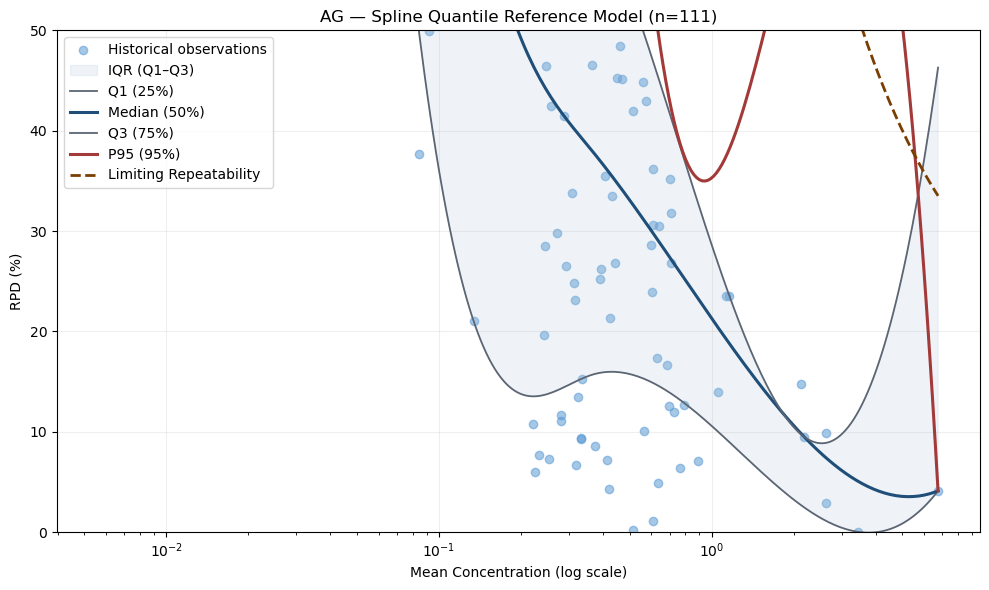

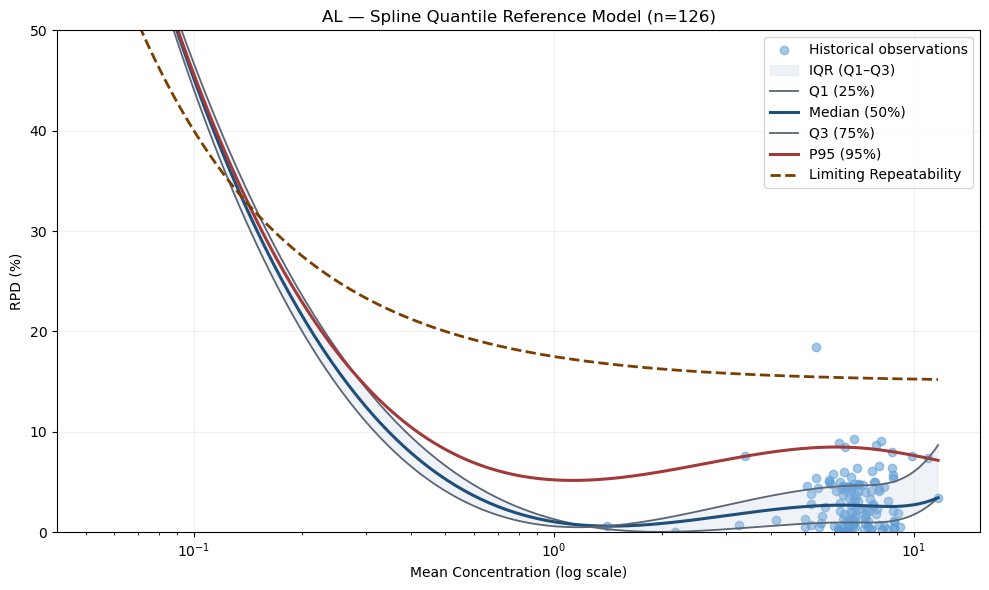

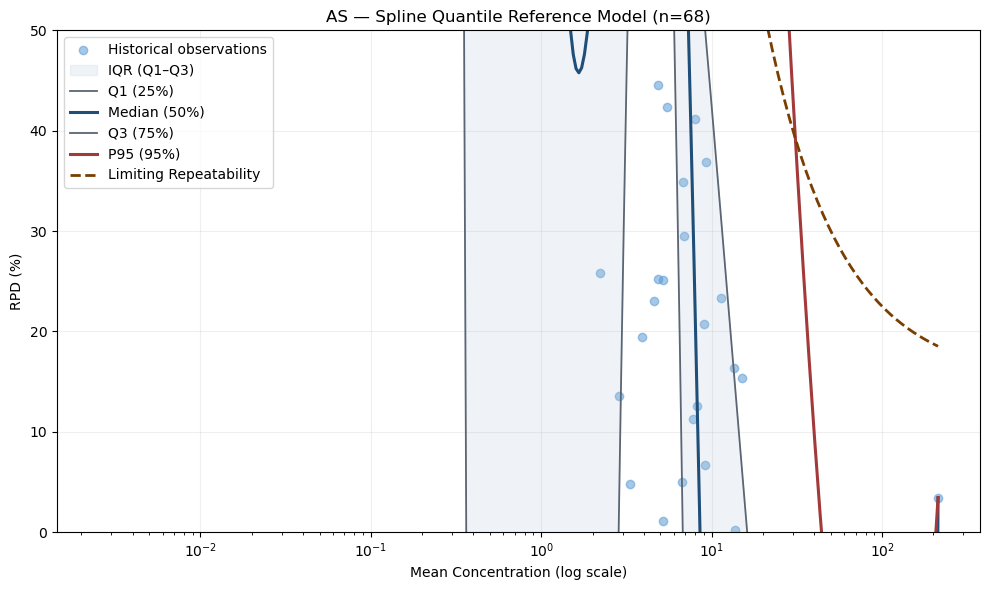

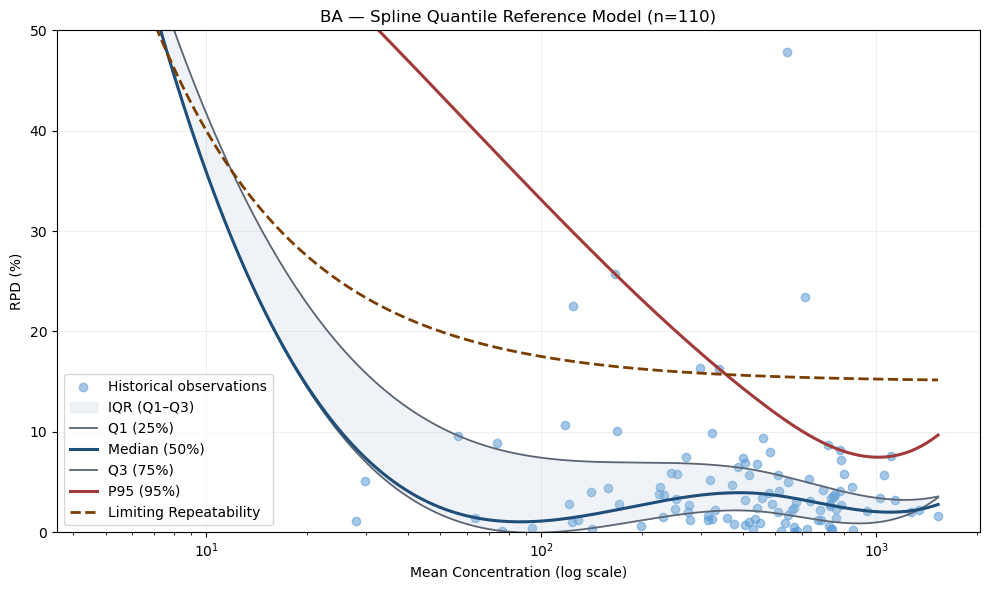

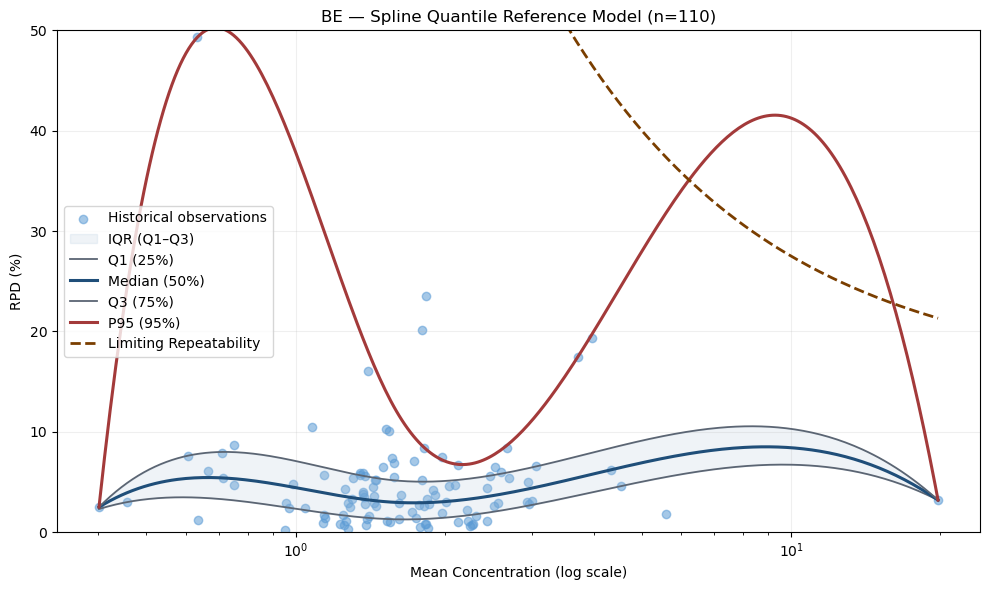

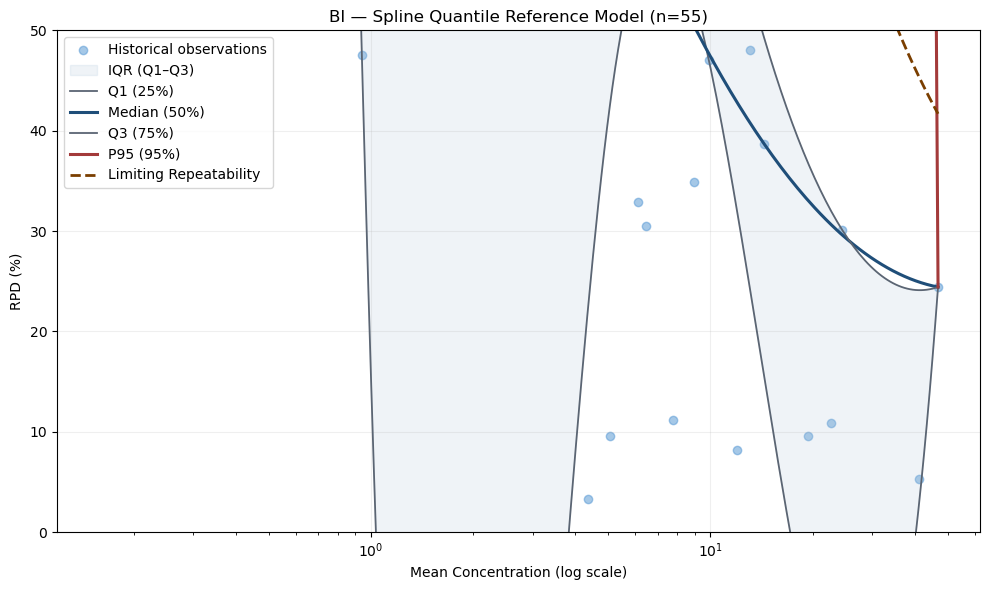

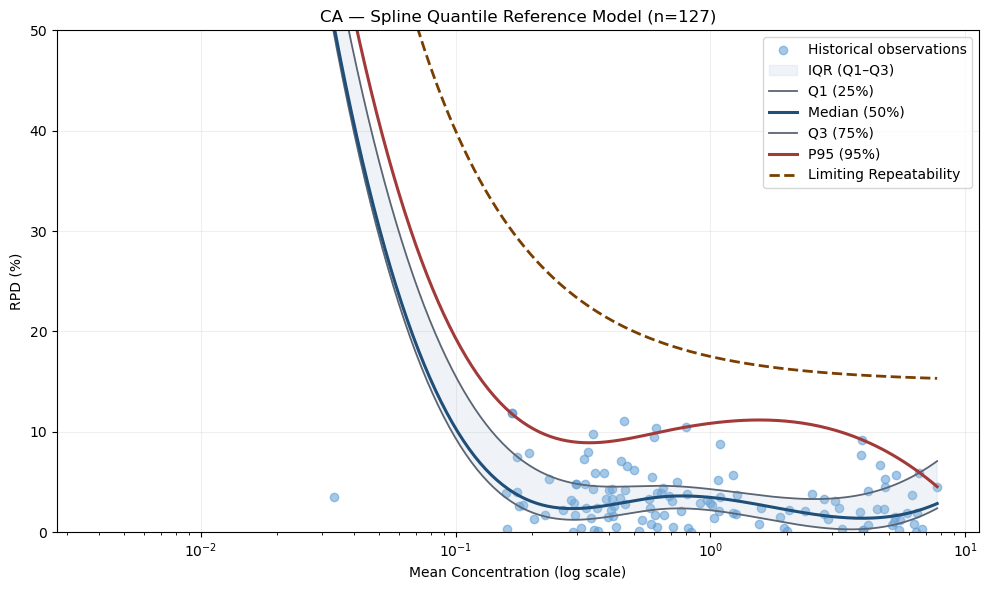

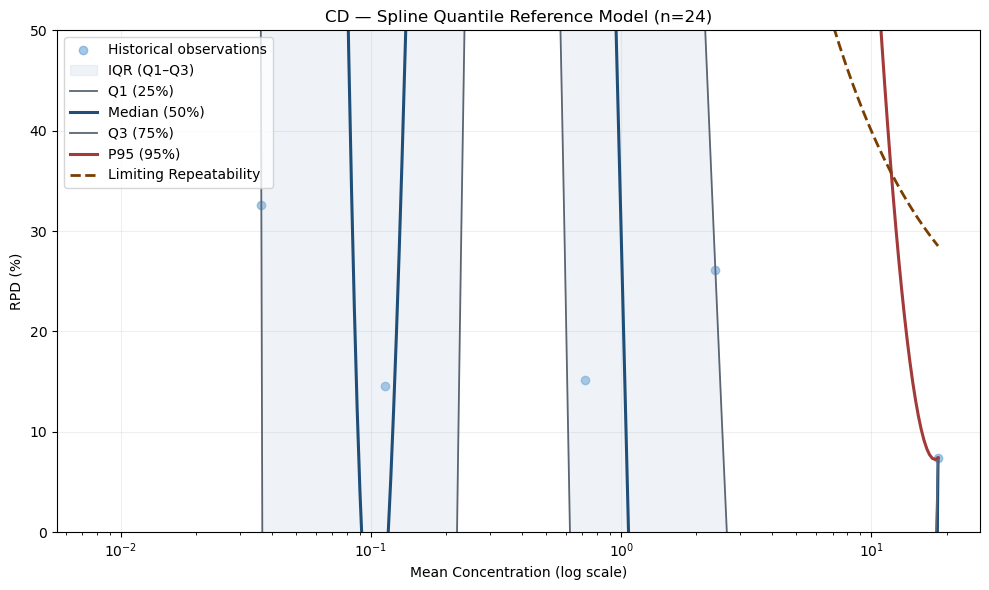

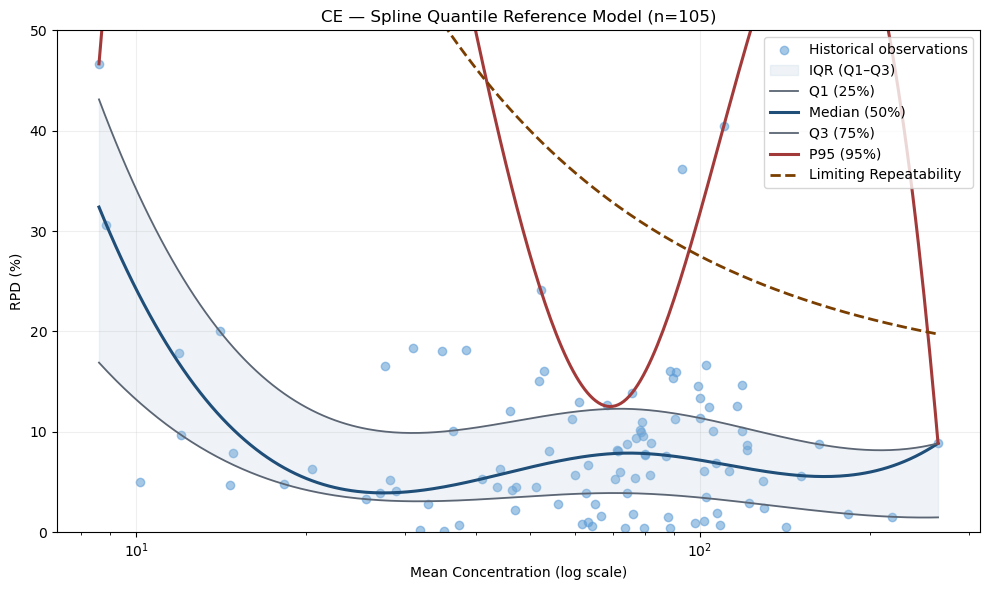

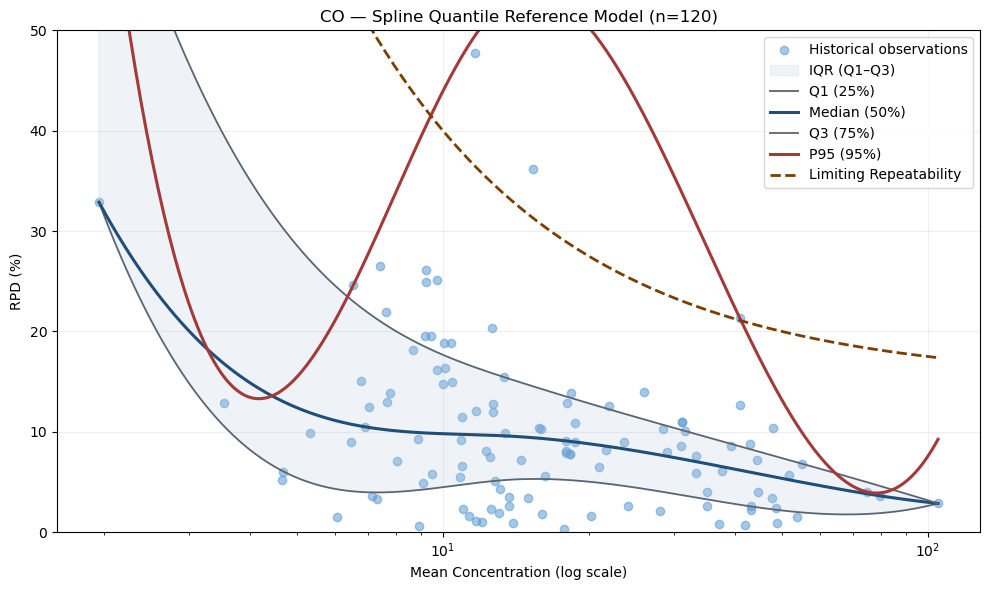

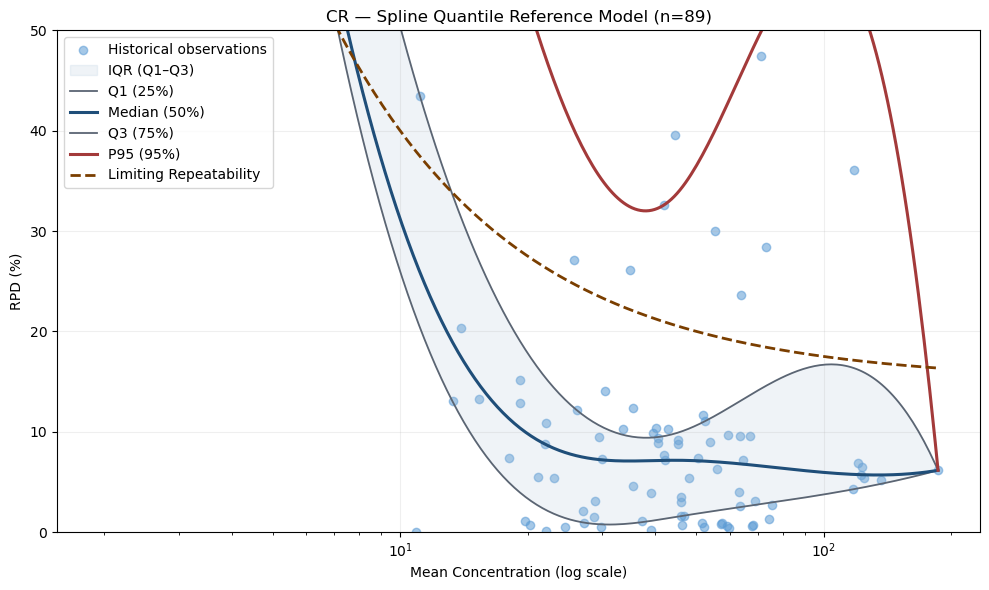

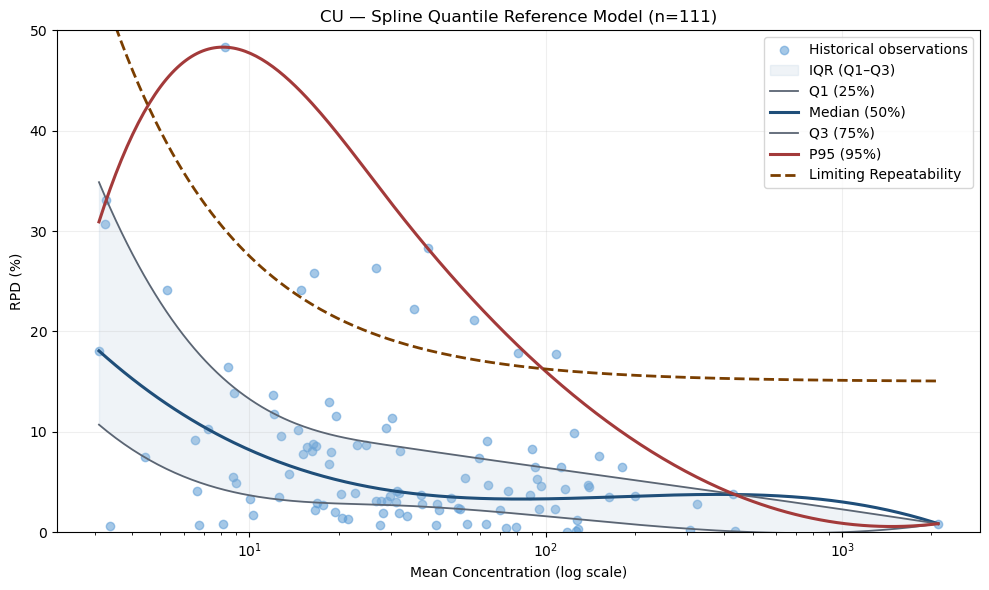

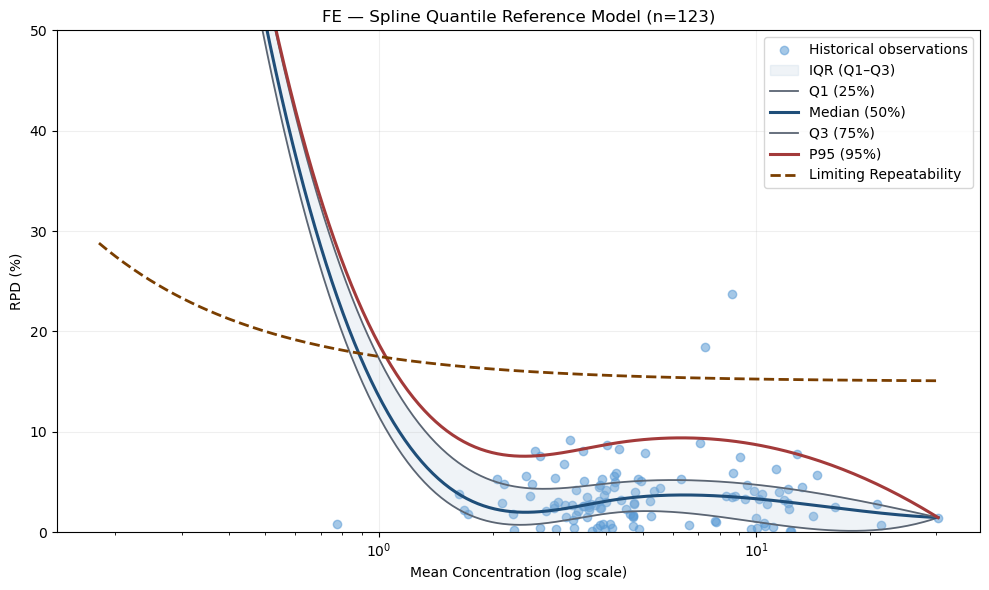

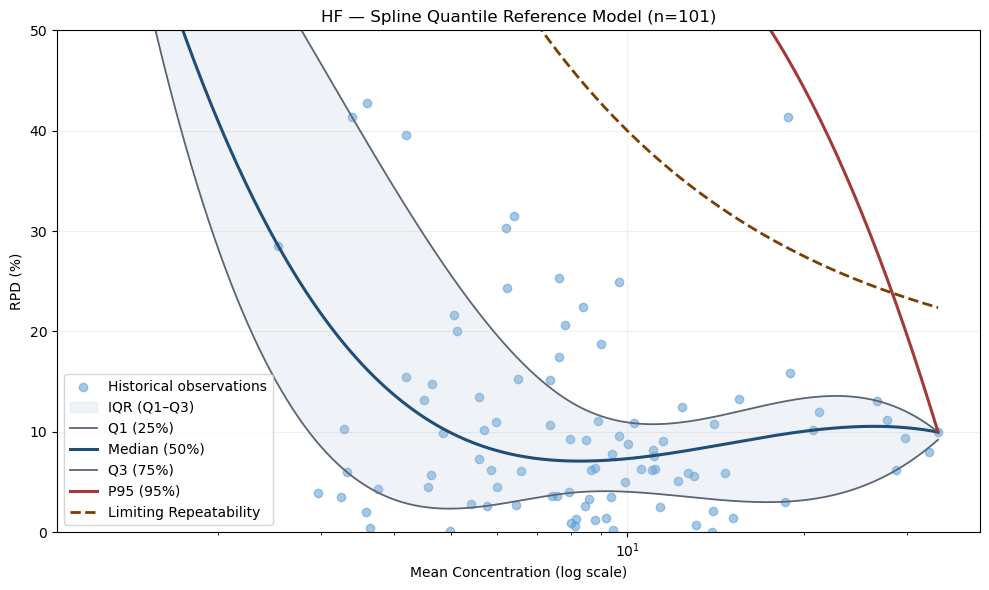

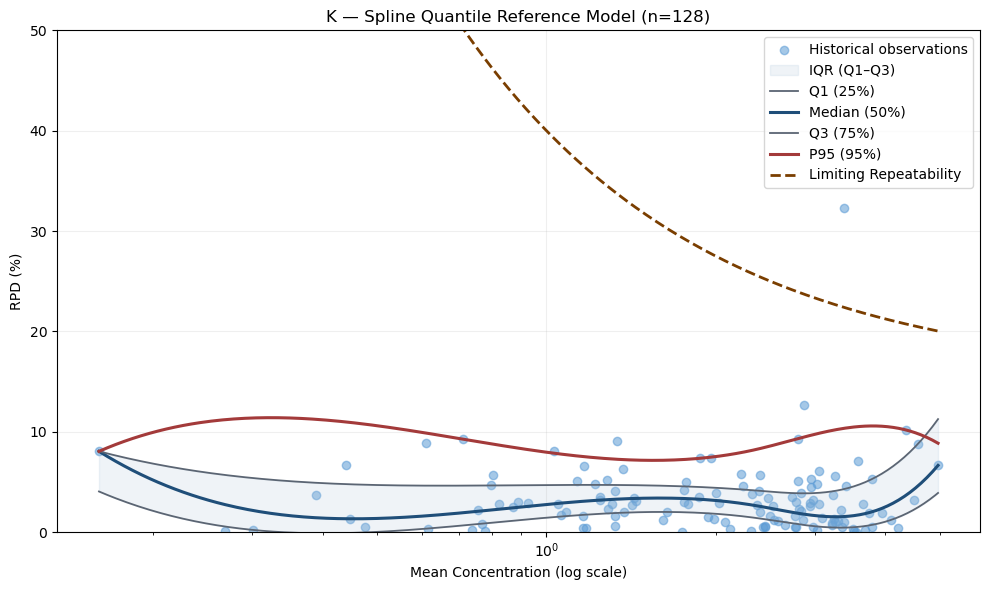

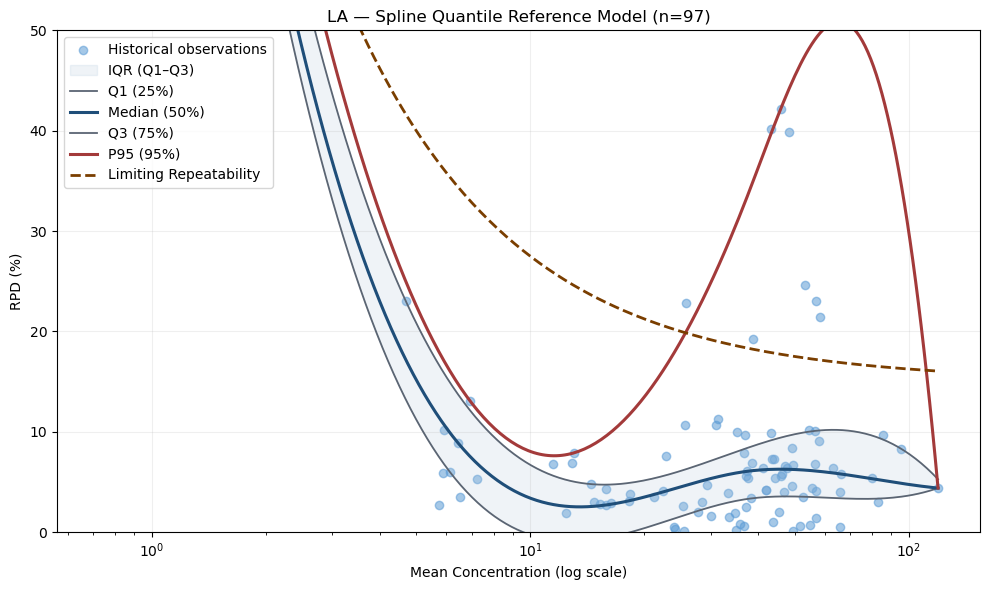

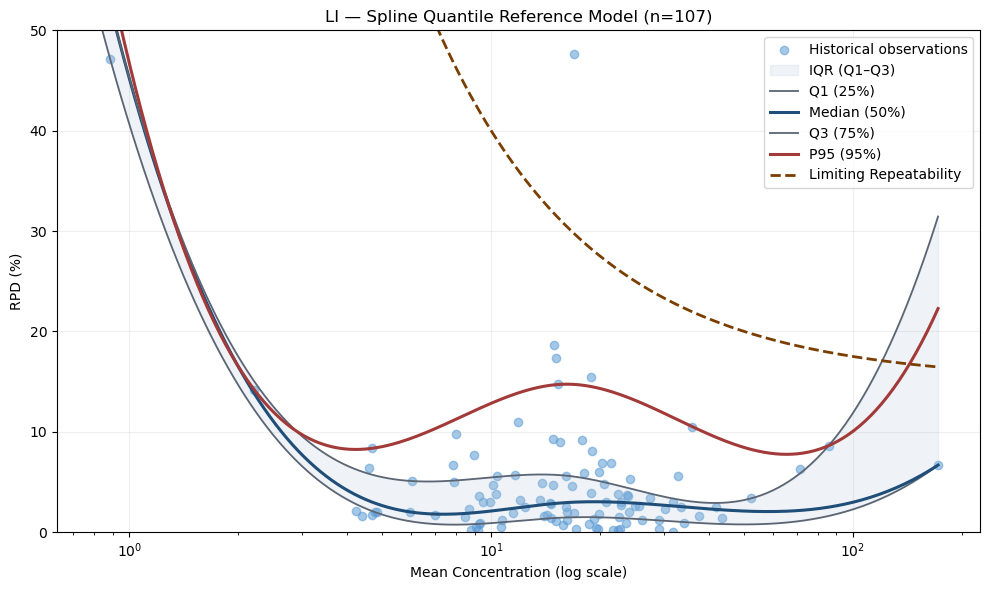

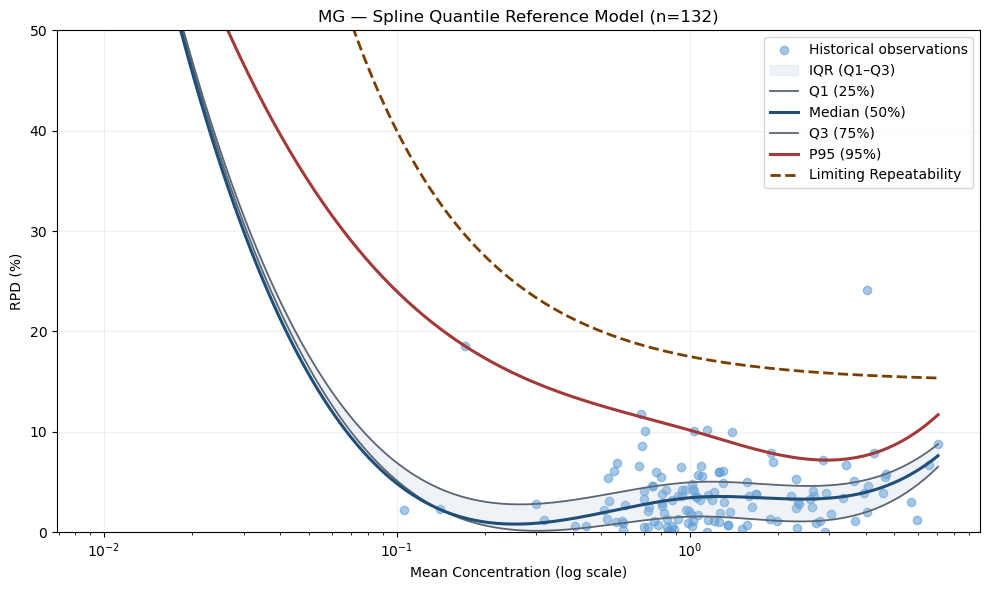

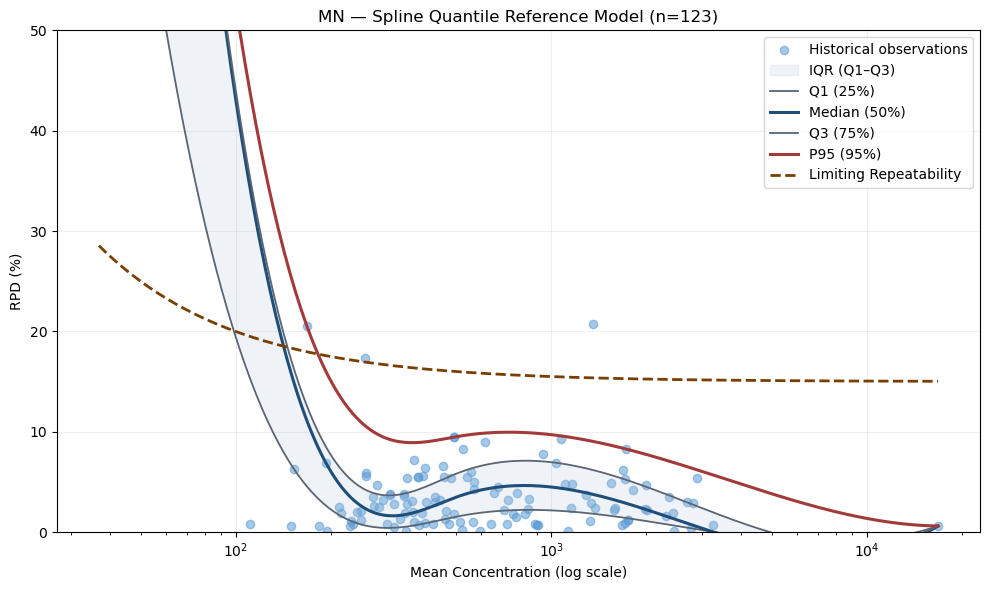

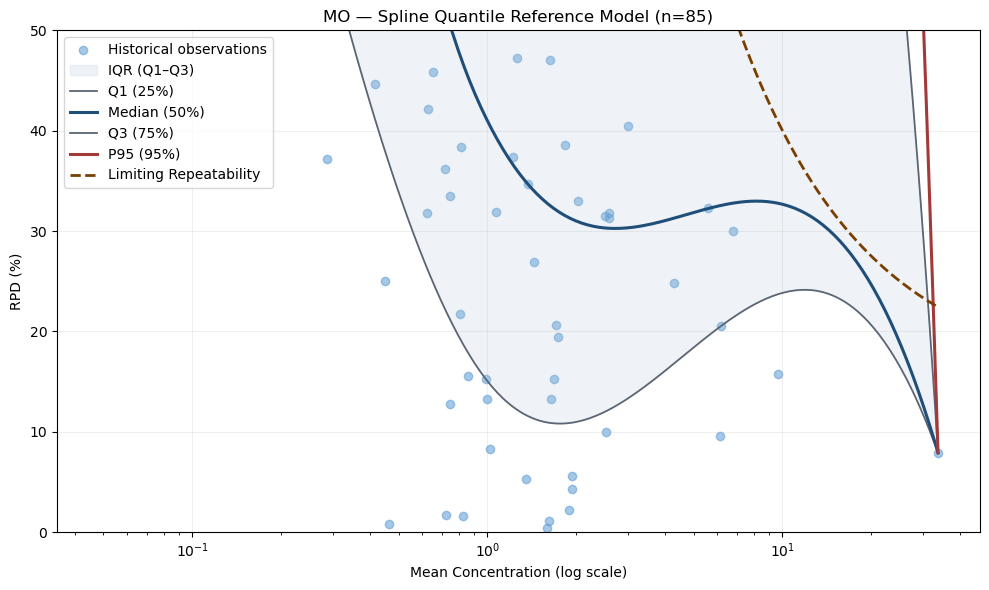

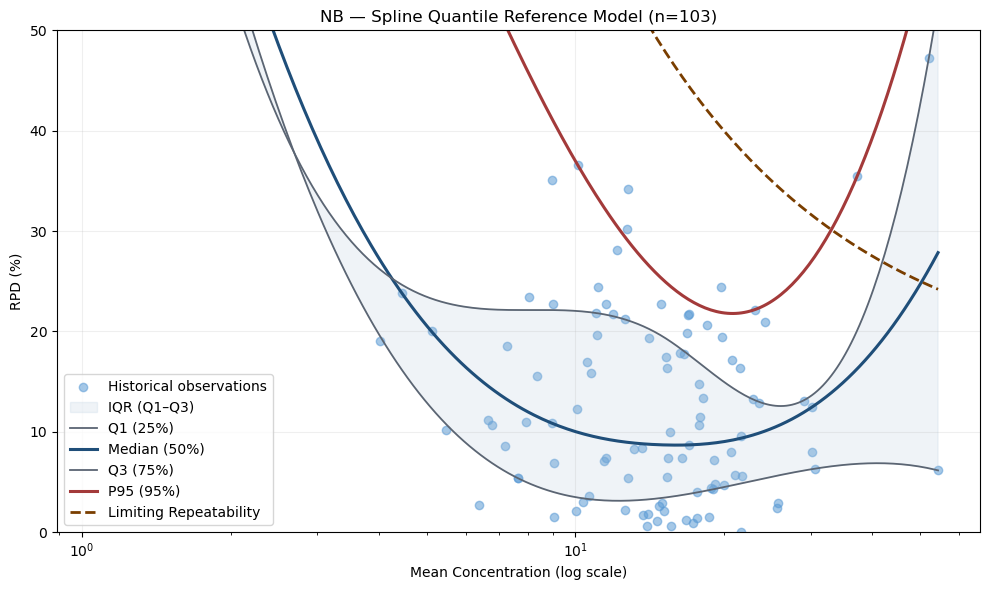

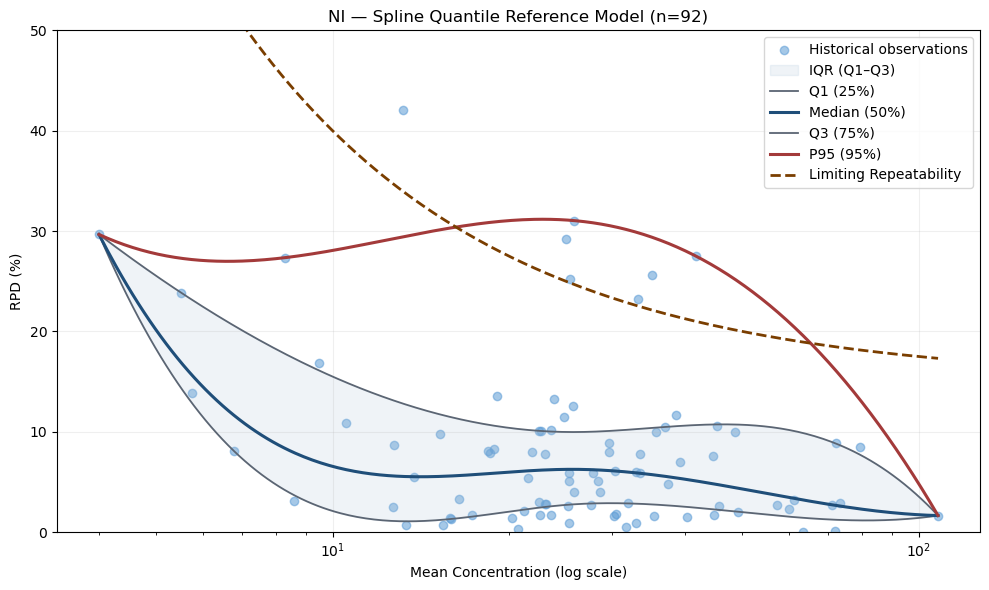

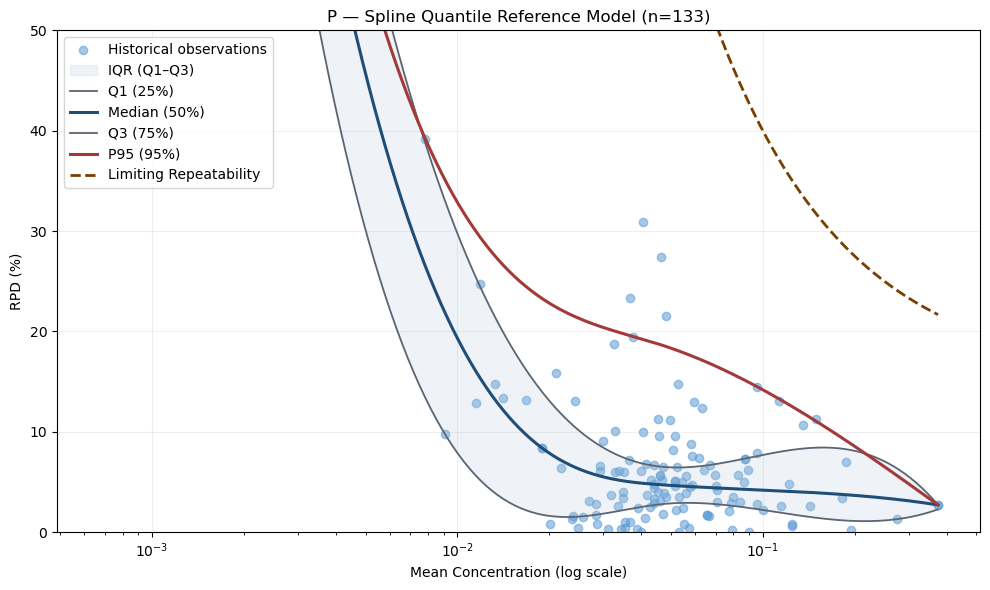

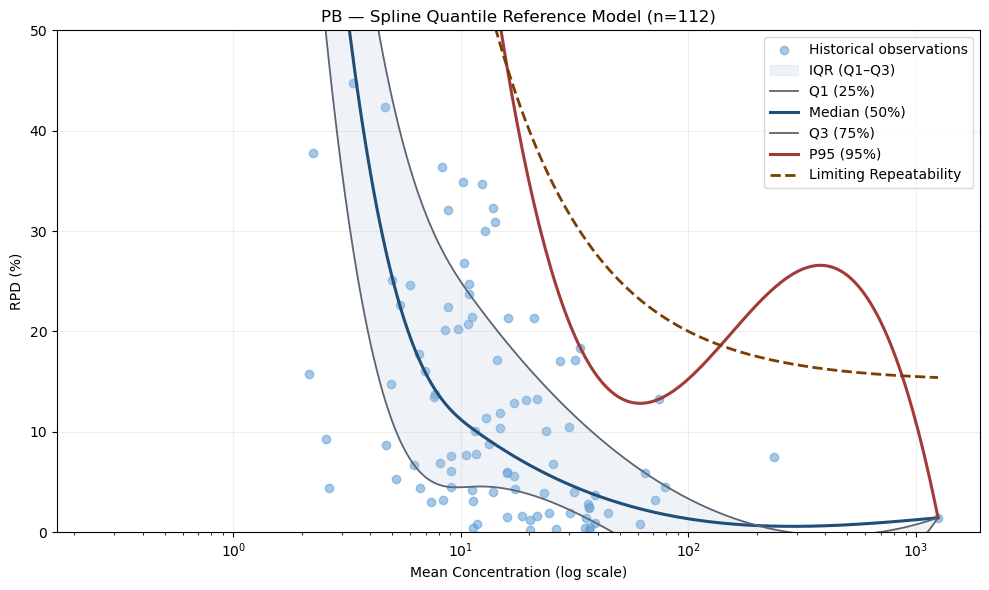

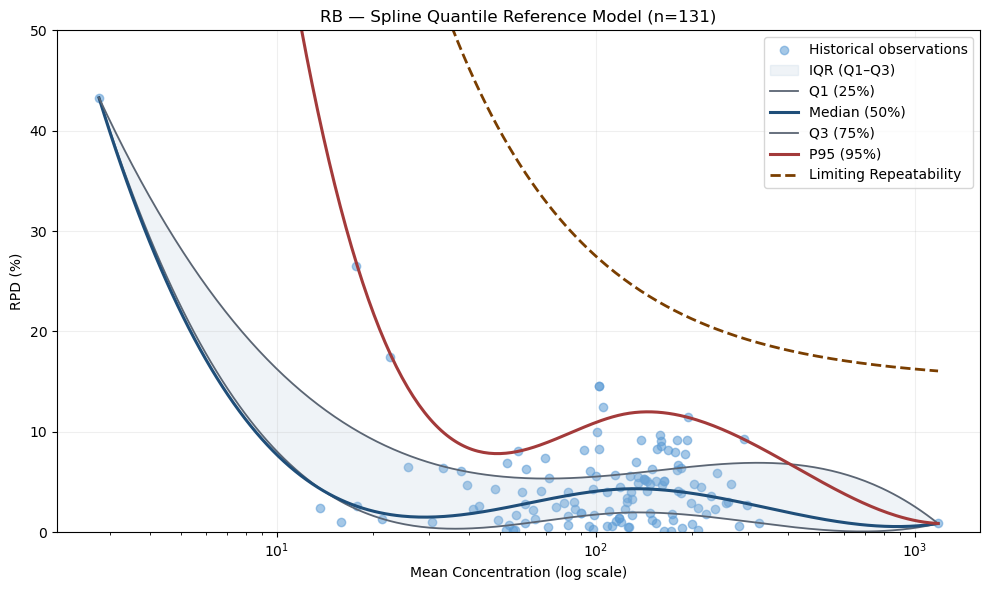

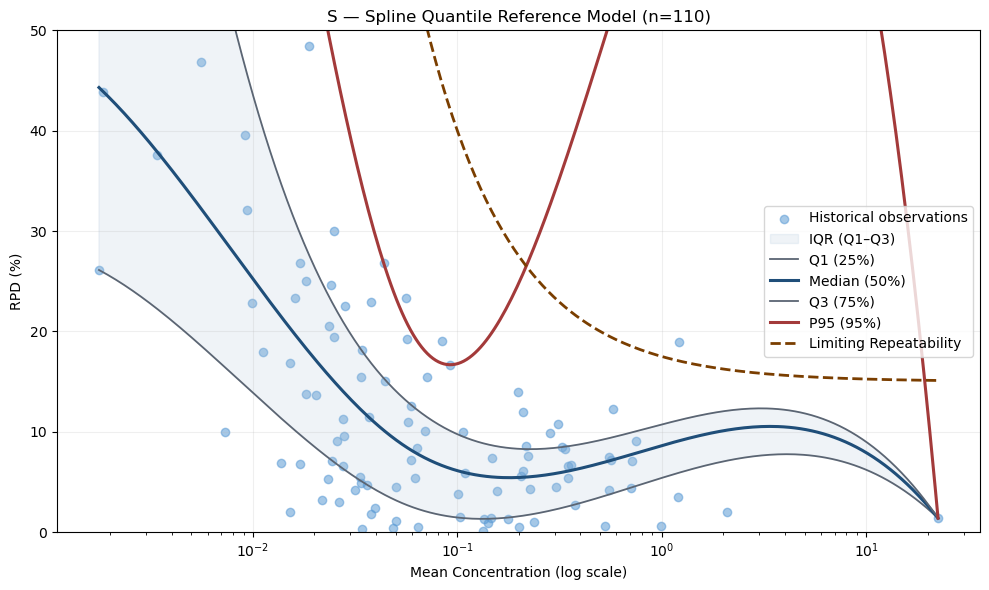

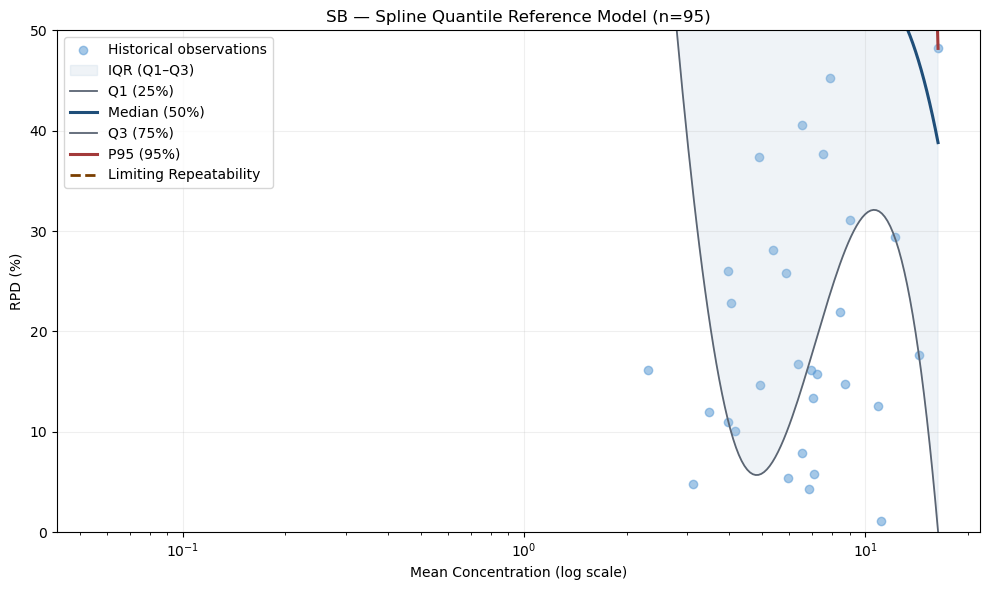

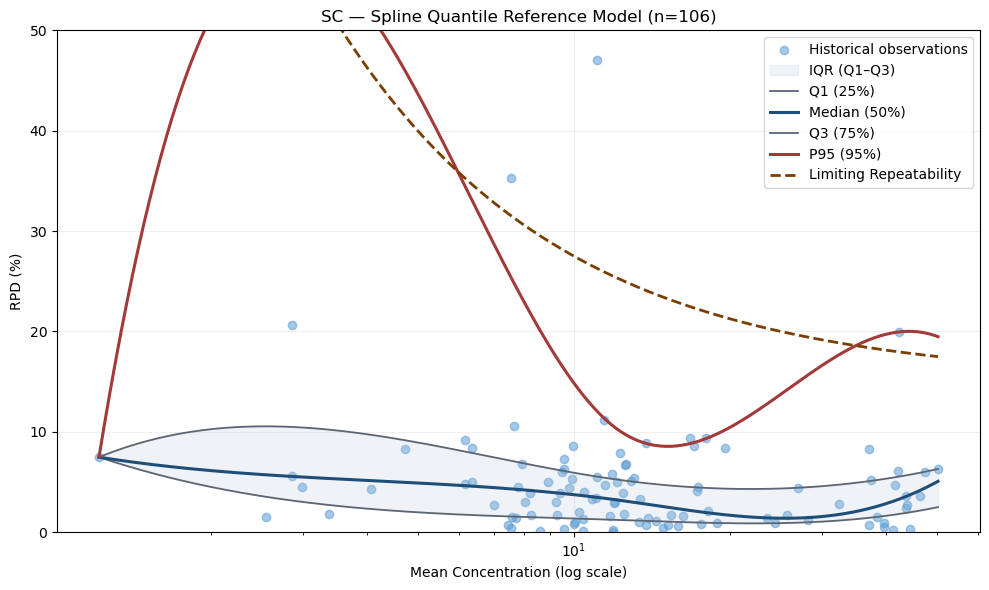

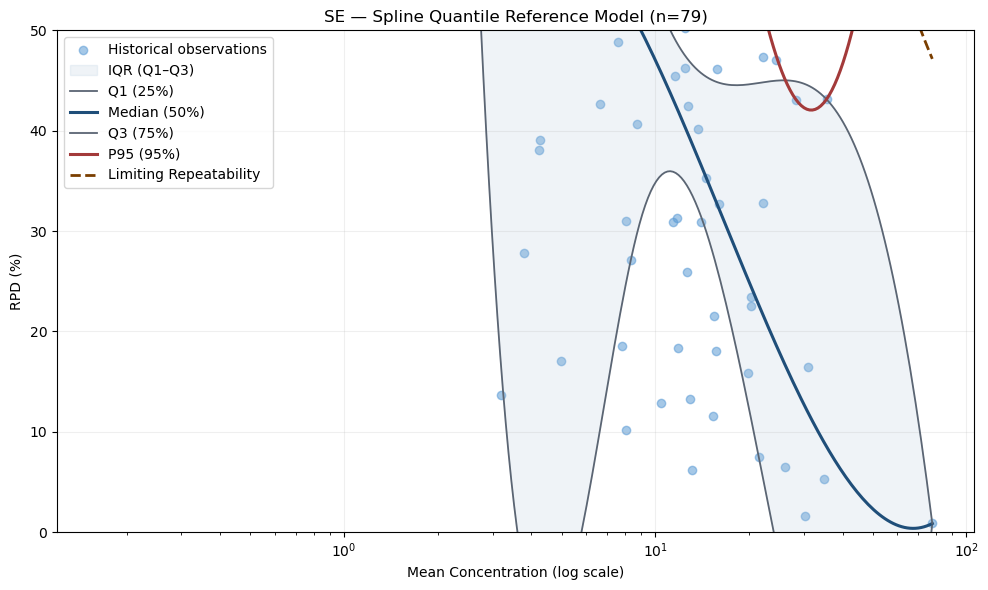

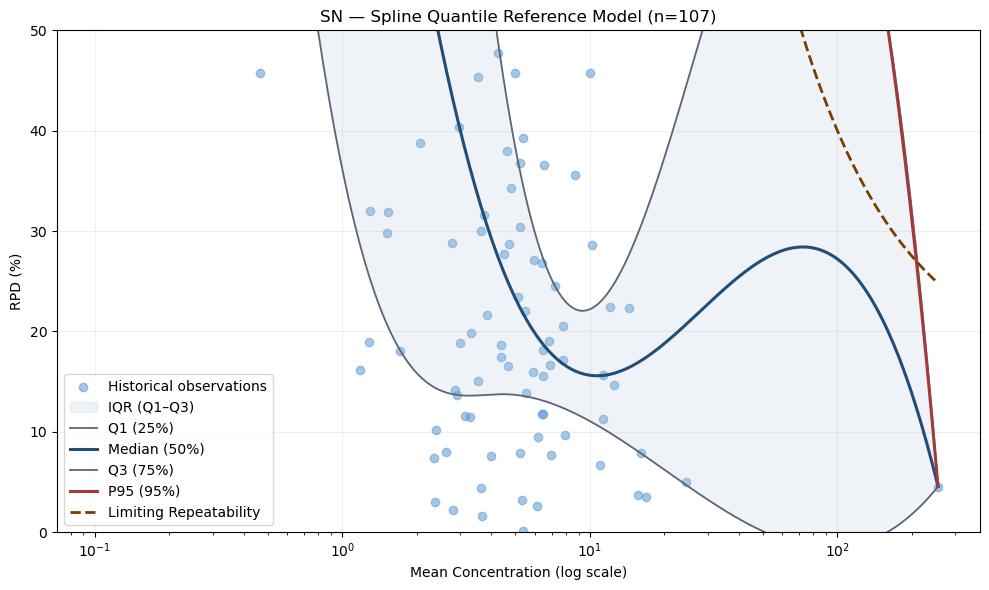

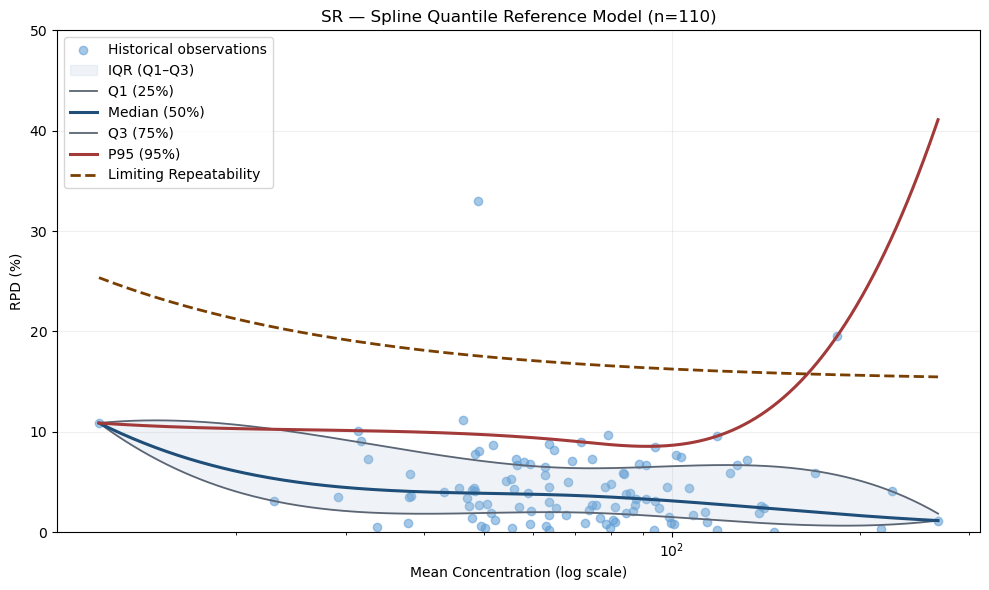

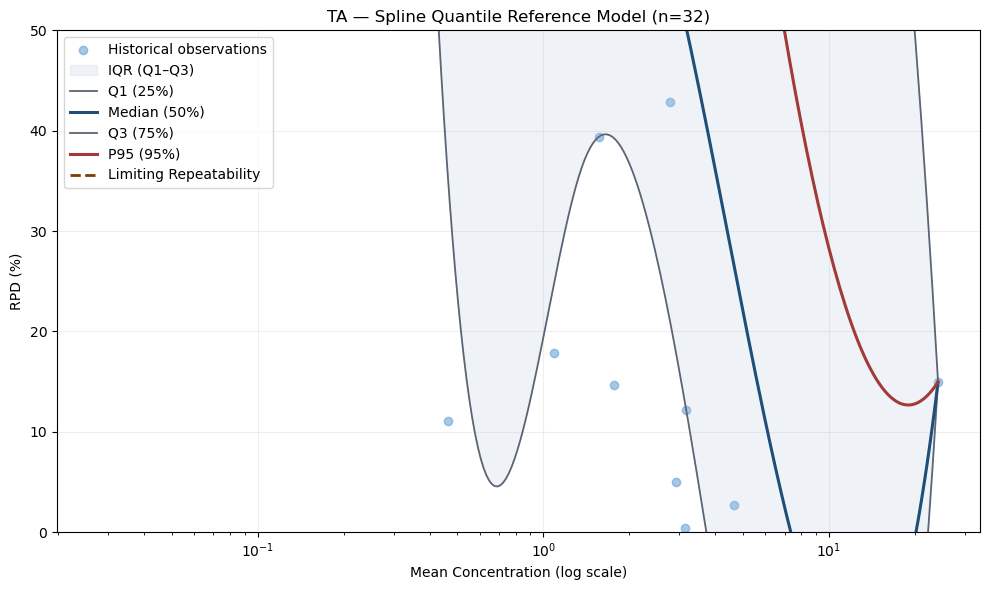

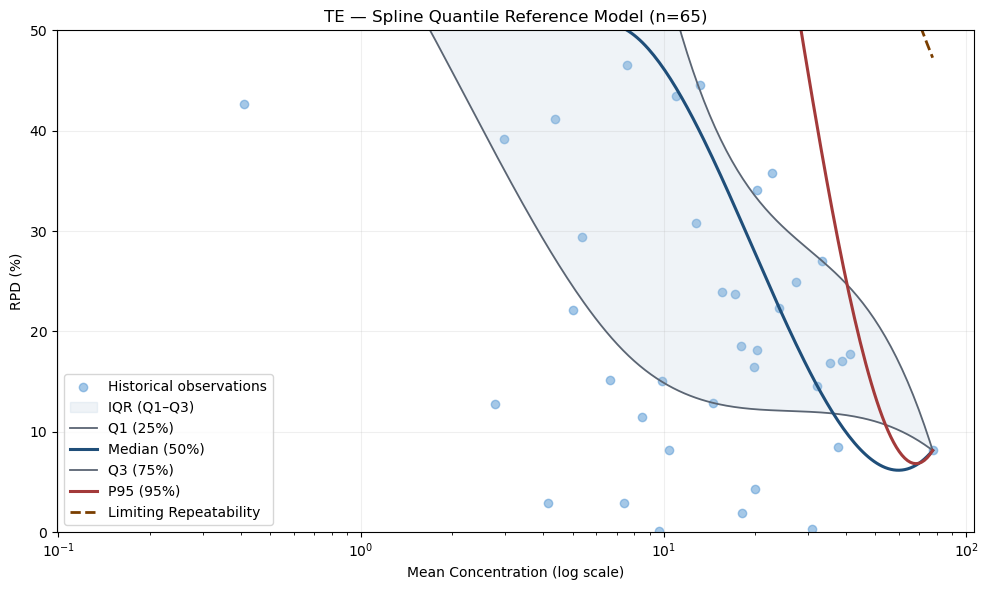

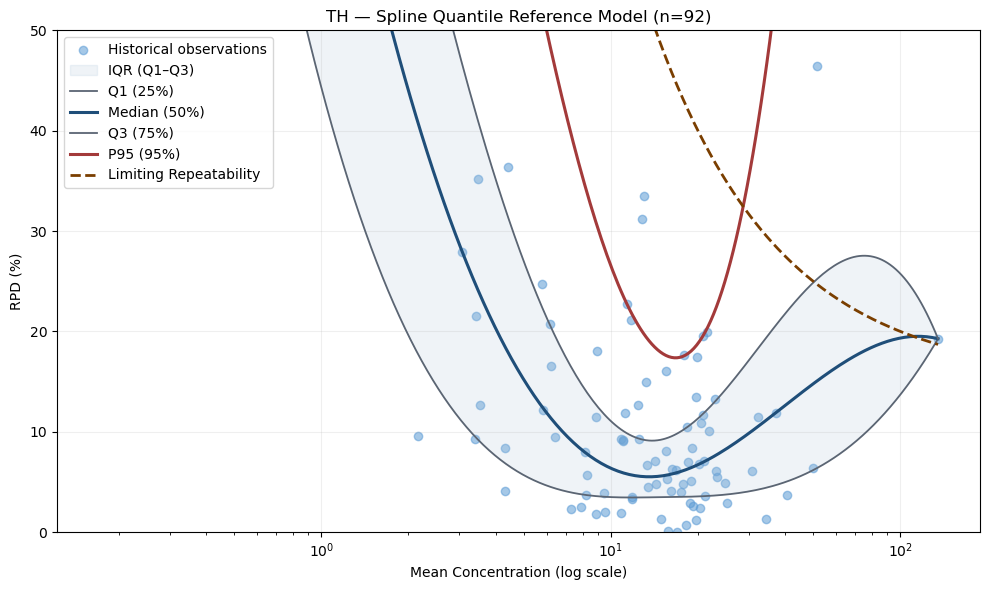

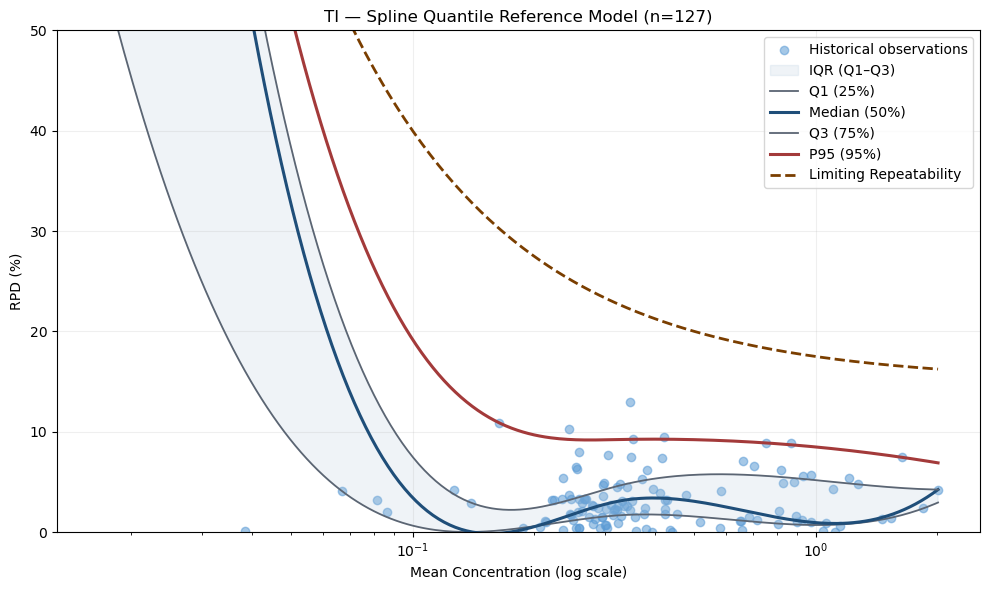

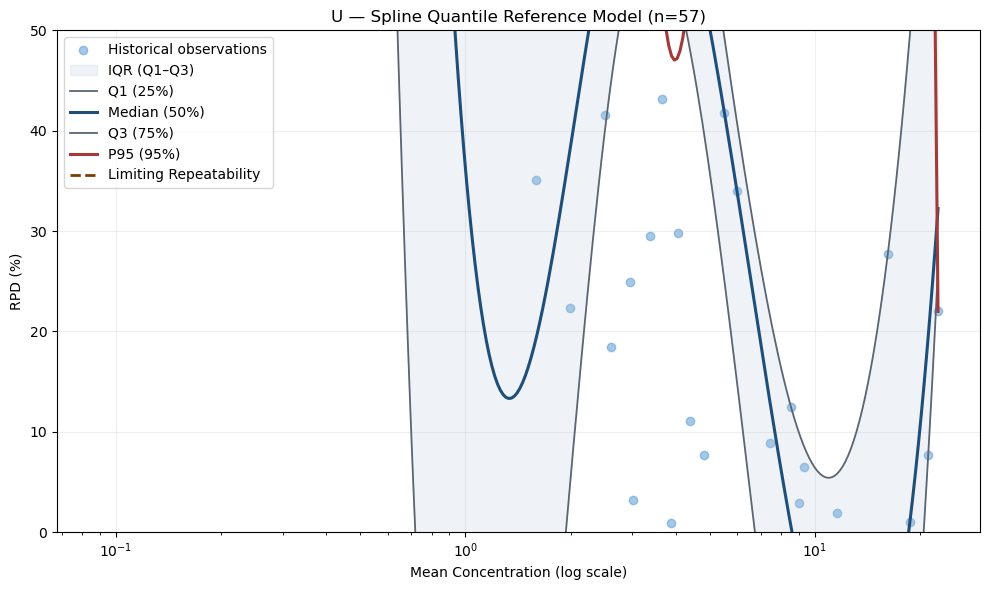

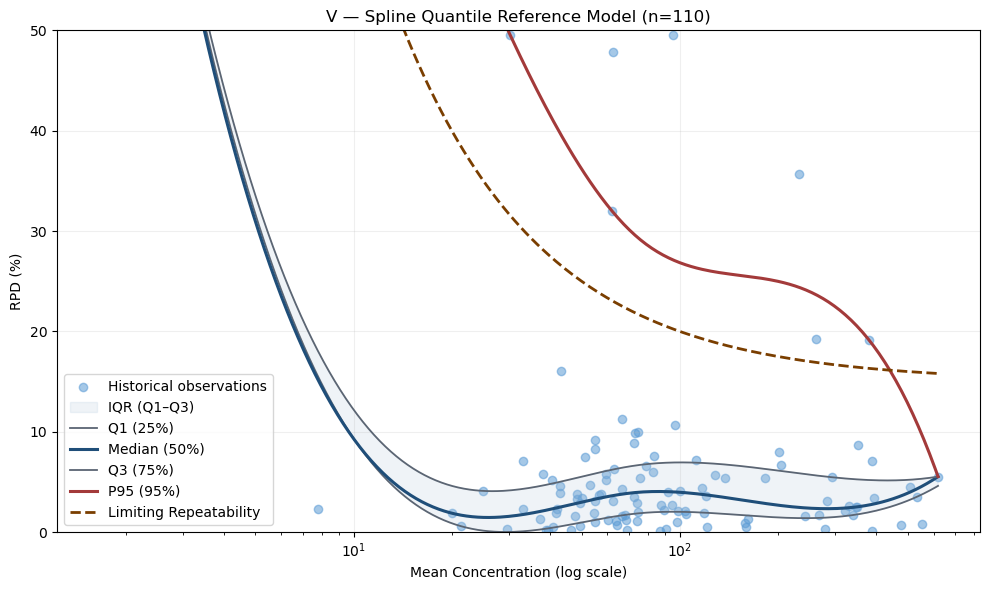

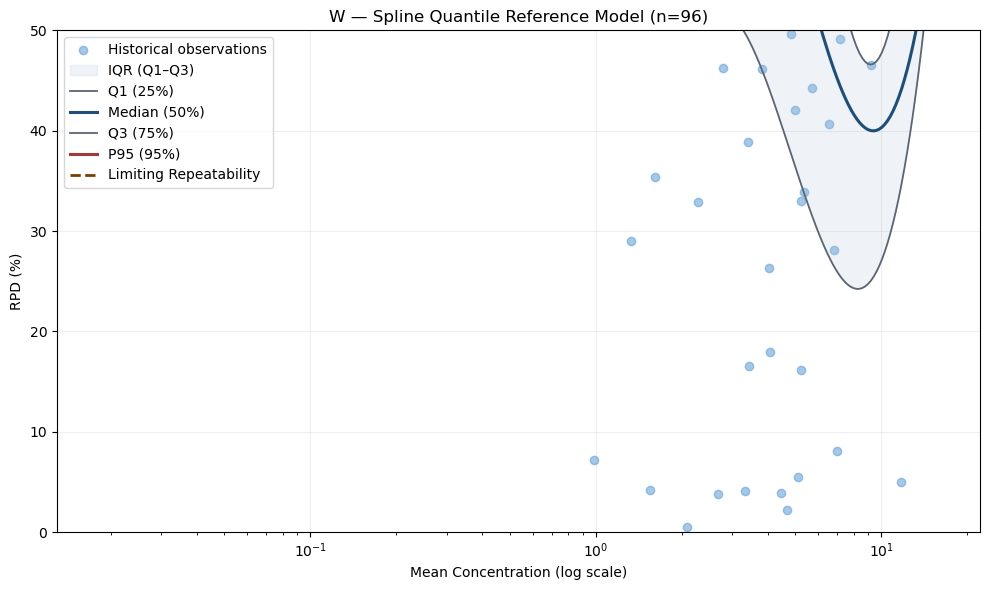

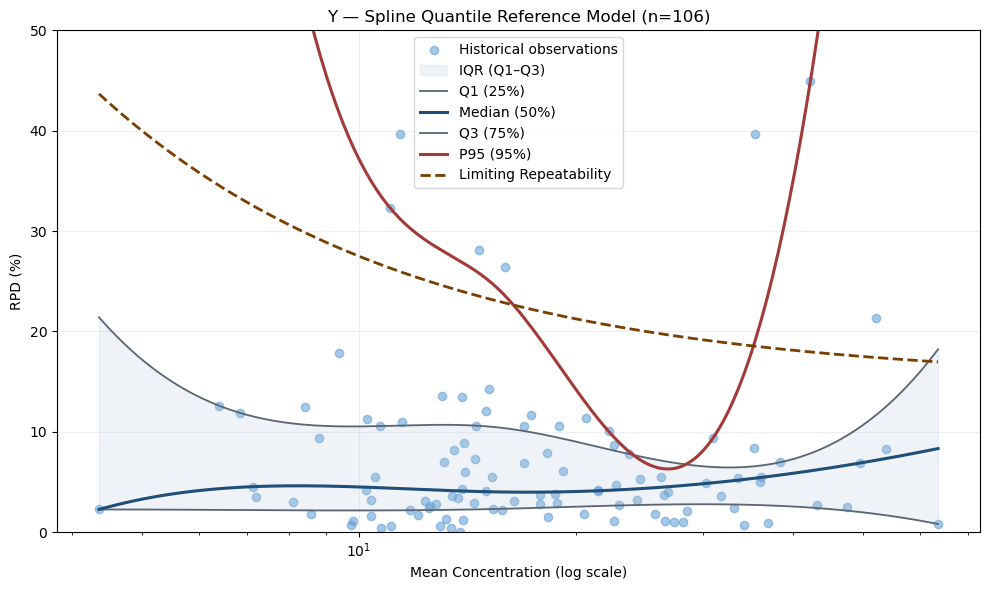

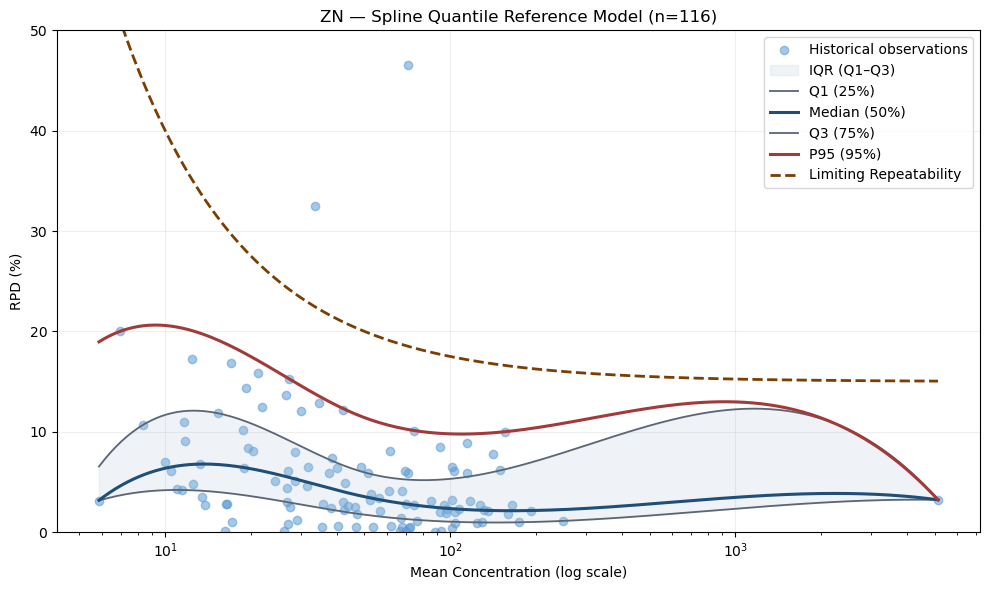

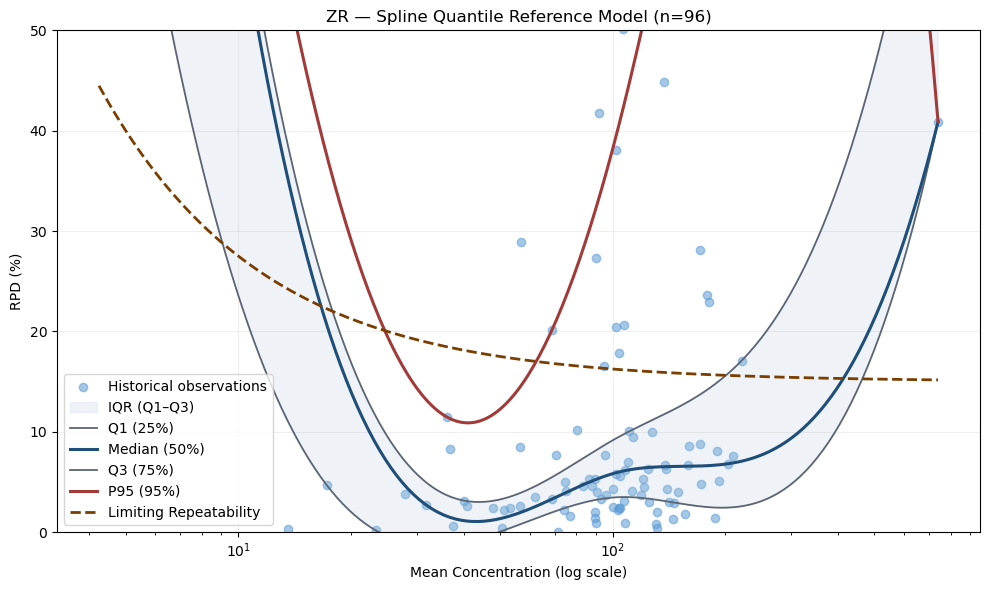

In [9]:
# Plot historical spline reference model and limiting repeatability
# for each Duplicate analyte

for analyte in MODEL_ANALYTES:

    # ---------------------------------------------------------
    # Select historical observations and reference predictions
    # ---------------------------------------------------------

    df_plot = (
        df_reference[
            df_reference["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    pred_plot = (
        reference_model_df[
            reference_model_df["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    # ---------------------------------------------------------
    # Plot reference model
    # ---------------------------------------------------------

    plt.figure(figsize=(10, 6))

    # Historical observations
    plt.scatter(
        df_plot["MEAN_CONC"],
        df_plot["RPD"],
        alpha=0.55,
        color=OBS_COLOUR,
        label="Historical observations"
    )

    # Interquartile reference band
    plt.fill_between(
        pred_plot["MEAN_CONC"],
        pred_plot["Q25"],
        pred_plot["Q75"],
        color=IQR_COLOUR,
        alpha=0.20,
        label="IQR (Q1–Q3)"
    )

    # Q1
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q25"],
        color=QUANTILE_COLOUR,
        linewidth=1.3,
        label="Q1 (25%)"
    )

    # Median
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q50"],
        color=MEDIAN_COLOUR,
        linewidth=2.2,
        label="Median (50%)"
    )

    # Q3
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q75"],
        color=QUANTILE_COLOUR,
        linewidth=1.3,
        label="Q3 (75%)"
    )

    # P95 historical upper reference
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q95"],
        color=P95_COLOUR,
        linewidth=2.2,
        label="P95 (95%)"
    )

    # Limiting Repeatability
    # Uses the value already calculated and persisted
    # in reference_model_df
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["ALLOWABLE_RPD"],
        color="#7A3E00",
        linestyle="--",
        linewidth=2.0,
        label="Limiting Repeatability"
    )

    # ---------------------------------------------------------
    # Chart formatting
    # ---------------------------------------------------------

    plt.xscale("log")
    plt.ylim(0, 50)

    plt.xlabel("Mean Concentration (log scale)")
    plt.ylabel("RPD (%)")

    plt.title(
        f"{analyte} — Spline Quantile Reference Model "
        f"(n={len(df_plot):,})"
    )

    plt.legend()
    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()
    

In [10]:
# Persist historical reference model

from pathlib import Path

# Root-level repository data/reference directory
OUTPUT_DIR = Path("../data/reference")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "DUP_historical_reference_model.csv"

# Write reference model
reference_model_df.to_csv(
    OUTPUT_FILE,
    index=False
)

# Confirm persisted output
print("Reference model saved to: data/reference/DUP_historical_reference_model.csv")
print(f"Rows written: {len(reference_model_df):,}")
print(
    f"Analytes written: "
    f"{reference_model_df['ANALYTE_CODE'].nunique()}"
)


Reference model saved to: data/reference/DUP_historical_reference_model.csv
Rows written: 12,300
Analytes written: 41
